In [1]:
# Import libraries
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Create output directory for processed arrays
os.makedirs("../data/processed", exist_ok=True)

In [3]:
# Load all CSV files
files = [f for f in os.listdir("../data/raw/MachineLearningCVE/") if f.endswith('.csv')]
print(f"Found {len(files)} files:")
for f in files:
    print(f"• {f}")

Found 8 files:
• Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
• Monday-WorkingHours.pcap_ISCX.csv
• Friday-WorkingHours-Morning.pcap_ISCX.csv
• Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
• Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
• Tuesday-WorkingHours.pcap_ISCX.csv
• Wednesday-workingHours.pcap_ISCX.csv
• Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv


In [4]:
# Combine data with progress tracking
dfs = []
for f in files:
    df = pd.read_csv(os.path.join("../data/raw/MachineLearningCVE/", f))
    dfs.append(df)
raw_df = pd.concat(dfs, ignore_index=True)

# Select and clean features
selected_features = [
    ' Flow Duration',
    ' Total Fwd Packets',
    ' Total Backward Packets',
    ' Total Length of Fwd Packets',
    ' Total Length of Bwd Packets',
    ' Flow Bytes/s',
    ' Flow Packets/s',
    ' FIN Flag Count',
    ' SYN Flag Count',
    ' ACK Flag Count',
    ' Packet Length Mean',
    ' Fwd Packet Length Mean',
    ' Bwd Packet Length Mean',
    ' Fwd Packet Length Max',
    ' Bwd Packet Length Min',
    ' Down/Up Ratio',
    ' Flow IAT Mean',
    ' Flow IAT Std',
    ' Active Mean',
    ' Idle Mean',
    ' Subflow Fwd Bytes'
]

selected_features = [col.strip() for col in selected_features]
raw_df.columns = raw_df.columns.str.strip()

df = raw_df[selected_features + ['Label']].copy()

# replacing infinity with NaN and then filling NaNs with 0
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

print("Null values remaining:", df.isnull().sum().sum())
print("Infinity values remaining:", np.isinf(df.select_dtypes(include=np.number)).sum().sum())

Null values remaining: 0
Infinity values remaining: 0


# Train-Test Split


In [5]:
print(df['Label'].value_counts())


# normal dataset (benign only)
normal_df = df[df['Label'] == 'BENIGN']

# attack dataset (everything else)
attack_df = df[df['Label'] != 'BENIGN']

print(f"\nNormal Flows: {len(normal_df)}")
print(f"Attack Flows: {len(attack_df)}")

# taking 80% benign data for training
X_train_benign, X_test_benign = train_test_split(normal_df, test_size=0.2, random_state=42)

# mixing remaining 20% benign data with all attack data for test dataset
test_mixed = pd.concat([X_test_benign, attack_df])

# dropping the 'Label' from training data for unsupervised learning
X_train = X_train_benign.drop('Label', axis=1)

# separating features and labels for test data
y_test = test_mixed['Label']
X_test = test_mixed.drop('Label', axis=1)


print(f"Training SHape(Benign Only): {X_train.shape}")
print(f"Testing SHape(Mixed): {X_test.shape}")


Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Normal Flows: 2273097
Attack Flows: 557646
Training SHape(Benign Only): (1818477, 21)
Testing SHape(Mixed): (1012266, 21)


# Normalization

In [6]:
scaler = StandardScaler()

# fit only training data (because in real life test data is unknown)
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Saving Data

In [ ]:
# training data
np.save("../data/processed/X_train.npy", X_train_scaled)

# test data
np.save("../data/processed/X_test.npy", X_test_scaled)

# label data
np.save("../data/processed/y_test.npy", y_test.to_numpy())

# scaler used by runtime predictor (ml_model/predict.py)
joblib.dump(scaler, "scaler.pkl")

['../models/scalar.pkl']

# Visualization

In [8]:
# # 1 before vs after Normalization
# # picking one feature ('Flow Duration')

# feature_index = 0 
# feature_name = selected_features[feature_index]
# plt.figure(figsize=(12, 5))

# # original 
# plt.subplot(1, 2, 1)
# sns.histplot(X_train[feature_name].iloc[:10000], bins=50, color='orange')
# plt.title(f"Original: {feature_name}(Huge Numbers)")
# plt.xlabel('Value')

# # scaled
# plt.subplot(1, 2, 2)
# sns.histplot(X_train_scaled[:10000, feature_index], bins=50, color='blue')
# plt.title(f"Original: {feature_name}(Centered at 0)")
# plt.xlabel('Value (Standard Deviation)')

# plt.tight_layout()
# plt.show()

/var/folders/n3/lsbnbfr506q92gbtjsmwsxs80000gn/T/ipykernel_79864/2078824412.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count_data.index, y=count_data.values, palette="viridis")


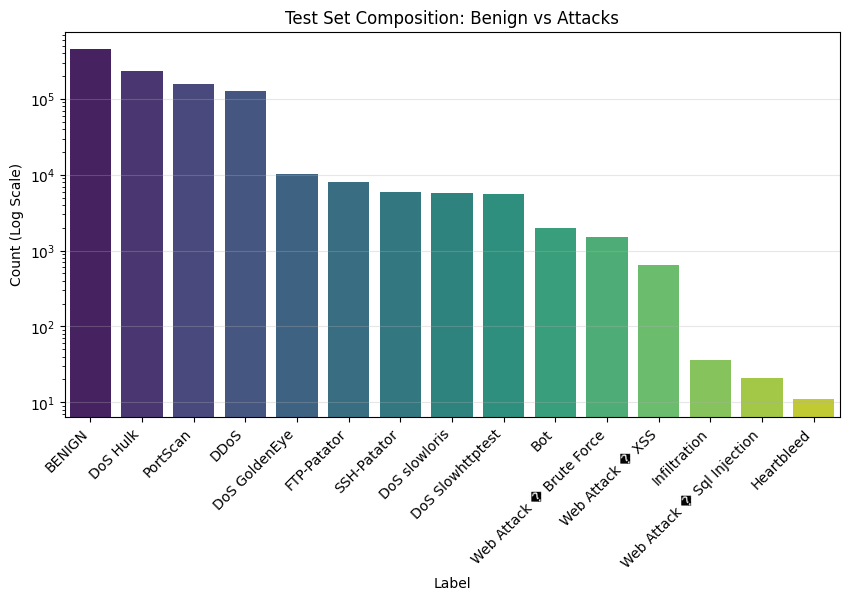

In [9]:
#2 label data distribution (y_test distribuition)

plt.figure(figsize=(10, 5))
count_data = y_test.value_counts()
sns.barplot(x=count_data.index, y=count_data.values, palette="viridis")
plt.title("Test Set Composition: Benign vs Attacks")
plt.xticks(rotation=45, ha='right')
plt.yscale('log')
plt.ylabel('Count (Log Scale)')
plt.grid(axis='y', alpha=0.3)
plt.show()
